<a href="https://colab.research.google.com/github/Ashkannappan/AR_Dashboard_Datase/blob/main/DL_Project_face_Mask_Detection_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle

In [2]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Importing Face Mask Dataset

In [3]:
# API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
 69% 113M/163M [00:00<00:00, 1.18GB/s]
100% 163M/163M [00:00<00:00, 1.08GB/s]


In [4]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [5]:
!ls

data  face-mask-dataset.zip  kaggle.json  sample_data  test1.jpg  test8.jpg


**Importing the Dependencies**

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [7]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_2281.jpg', 'with_mask_1007.jpg', 'with_mask_393.jpg', 'with_mask_1796.jpg', 'with_mask_3393.jpg']
['with_mask_1404.jpg', 'with_mask_1425.jpg', 'with_mask_2090.jpg', 'with_mask_1221.jpg', 'with_mask_1472.jpg']


In [8]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_2151.jpg', 'without_mask_1298.jpg', 'without_mask_645.jpg', 'without_mask_3645.jpg', 'without_mask_3827.jpg']
['without_mask_1519.jpg', 'without_mask_2311.jpg', 'without_mask_2820.jpg', 'without_mask_2817.jpg', 'without_mask_3699.jpg']


In [9]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


**Creating Labels for the two class of Images**

with mask  -->  1

without mask  -->  0

In [10]:
# create the labels

with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [11]:
print(with_mask_labels[0:5])

print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [12]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [13]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


**Displaying the Images**

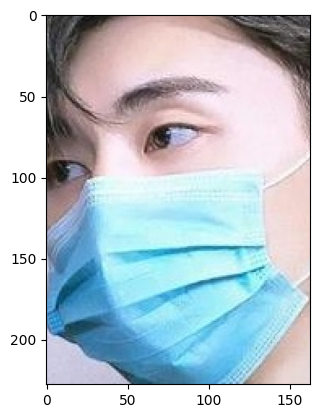

In [14]:
# displaying with mask image
img = mpimg.imread('/content/data/with_mask/with_mask_1545.jpg')
imgplot = plt.imshow(img)
plt.show()

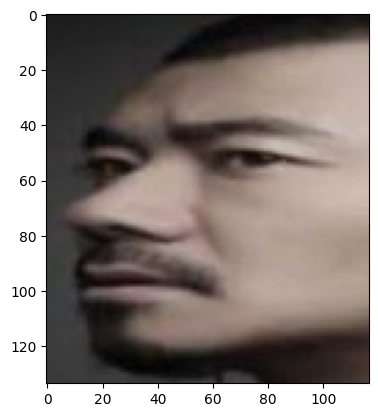

In [15]:
# displaying without mask image
img = mpimg.imread('/content/data/without_mask/without_mask_16.jpg')
imgplot = plt.imshow(img)
plt.show()

**Image Processing**

1. Resize the Images

2. Convert the images to numpy arrays

In [16]:
# convert images to numpy arrays+

with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



without_mask_path = '/content/data/without_mask/'


for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [17]:
type(data)

list

In [18]:
len(data)

7553

array([[[205, 205, 205],
        [209, 209, 209],
        [221, 221, 221],
        ...,
        [213, 210, 213],
        [214, 206, 207],
        [216, 208, 208]],

       [[208, 208, 208],
        [172, 172, 172],
        [129, 129, 129],
        ...,
        [152, 171, 174],
        [180, 195, 195],
        [208, 211, 210]],

       [[215, 215, 215],
        [121, 121, 121],
        [  0,   0,   0],
        ...,
        [ 84, 115, 122],
        [151, 178, 183],
        [203, 213, 215]],

       ...,

       [[ 28,  14,  16],
        [ 23,  13,  14],
        [ 12,   7,   7],
        ...,
        [ 92,  95,   9],
        [166, 163, 111],
        [216, 211, 203]],

       [[ 27,  14,  17],
        [ 32,  22,  24],
        [ 28,  22,  22],
        ...,
        [169, 167, 113],
        [200, 193, 172],
        [214, 209, 215]],

       [[ 25,  14,  15],
        [ 41,  32,  30],
        [ 44,  35,  31],
        ...,
        [216, 212, 203],
        [212, 206, 213],
        [210, 206, 217]]], dtype=uint8)
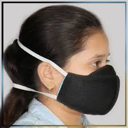

In [19]:
data[0]

In [20]:
type(data[0])

numpy.ndarray

In [21]:
data[0].shape

(128, 128, 3)

In [22]:
# converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [23]:
type(X)

numpy.ndarray

In [24]:
type(Y)

numpy.ndarray

In [25]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [26]:
print(Y)

[1 1 1 ... 0 0 0]


**Train Test Split**

In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [28]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [29]:
# scaling the data

X_train_scaled = X_train/255

X_test_scaled = X_test/255

array([[[255, 225, 211],
        [205, 170, 156],
        [173, 139, 126],
        ...,
        [ 97,  63,  62],
        [ 99,  65,  64],
        [104,  70,  69]],

       [[247, 211, 197],
        [209, 172, 158],
        [175, 141, 128],
        ...,
        [ 89,  55,  54],
        [ 94,  60,  59],
        [ 98,  64,  63]],

       [[151, 115, 101],
        [160, 124, 110],
        [145, 110,  98],
        ...,
        [ 84,  50,  49],
        [ 91,  57,  56],
        [ 95,  61,  60]],

       ...,

       [[161, 144, 126],
        [162, 145, 127],
        [163, 147, 130],
        ...,
        [250,  61, 101],
        [244,  55,  95],
        [238,  52,  89]],

       [[161, 144, 126],
        [163, 146, 128],
        [163, 147, 131],
        ...,
        [245,  56,  96],
        [240,  52,  90],
        [237,  51,  88]],

       [[159, 142, 124],
        [161, 144, 126],
        [161, 145, 129],
        ...,
        [244,  55,  93],
        [245,  56,  94],
        [243,  57,  94]]], dtype=uint8)
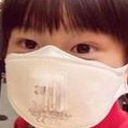

In [30]:
X_train[0]

In [31]:
X_train_scaled[0]

array([[[1.        , 0.88235294, 0.82745098],
        [0.80392157, 0.66666667, 0.61176471],
        [0.67843137, 0.54509804, 0.49411765],
        ...,
        [0.38039216, 0.24705882, 0.24313725],
        [0.38823529, 0.25490196, 0.25098039],
        [0.40784314, 0.2745098 , 0.27058824]],

       [[0.96862745, 0.82745098, 0.77254902],
        [0.81960784, 0.6745098 , 0.61960784],
        [0.68627451, 0.55294118, 0.50196078],
        ...,
        [0.34901961, 0.21568627, 0.21176471],
        [0.36862745, 0.23529412, 0.23137255],
        [0.38431373, 0.25098039, 0.24705882]],

       [[0.59215686, 0.45098039, 0.39607843],
        [0.62745098, 0.48627451, 0.43137255],
        [0.56862745, 0.43137255, 0.38431373],
        ...,
        [0.32941176, 0.19607843, 0.19215686],
        [0.35686275, 0.22352941, 0.21960784],
        [0.37254902, 0.23921569, 0.23529412]],

       ...,

       [[0.63137255, 0.56470588, 0.49411765],
        [0.63529412, 0.56862745, 0.49803922],
        [0.63921569, 0

**Building a Convolutional Neural Networks (CNN)**

In [32]:
import tensorflow as tf
from tensorflow import keras

In [33]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))


model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
# compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [35]:
# training the neural network
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - acc: 0.7103 - loss: 0.6345 - val_acc: 0.8810 - val_loss: 0.2819
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.8942 - loss: 0.2723 - val_acc: 0.8942 - val_loss: 0.2448
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9057 - loss: 0.2441 - val_acc: 0.9058 - val_loss: 0.2144
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.9331 - loss: 0.1782 - val_acc: 0.9190 - val_loss: 0.2032
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - acc: 0.9375 - loss: 0.1667 - val_acc: 0.9256 - val_loss: 0.1946


**Model Evaluation**

In [36]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.9235 - loss: 0.2114
Test Accuracy = 0.9291859865188599


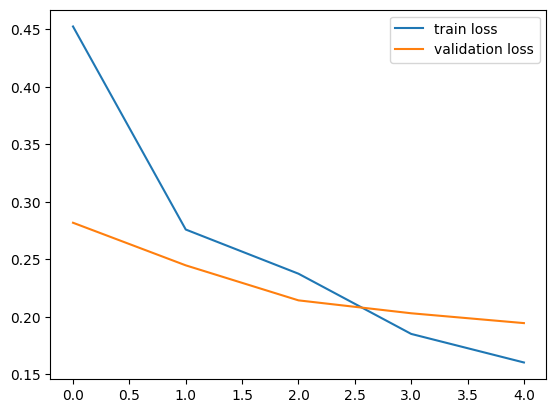

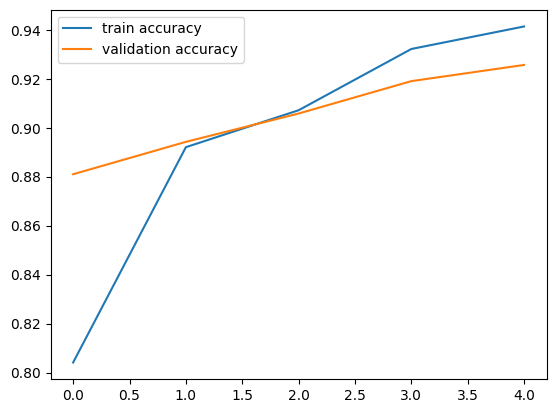

In [37]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

**Predictive System**

Path of the image to be predicted: /content/test1.jpg


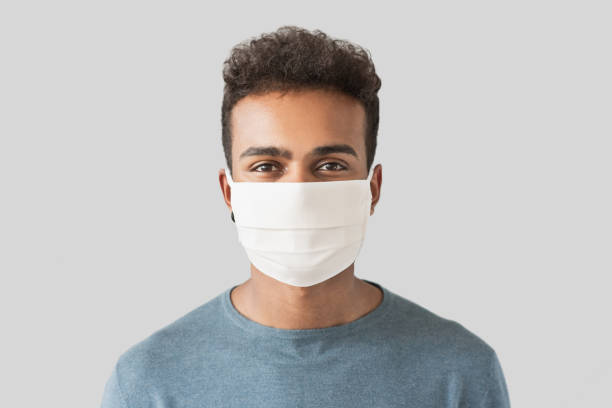

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
[[0.48329622 0.5360688 ]]
1
The person in the image is wearing a mask


In [38]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')

Path of the image to be predicted: /content/test8.jpg


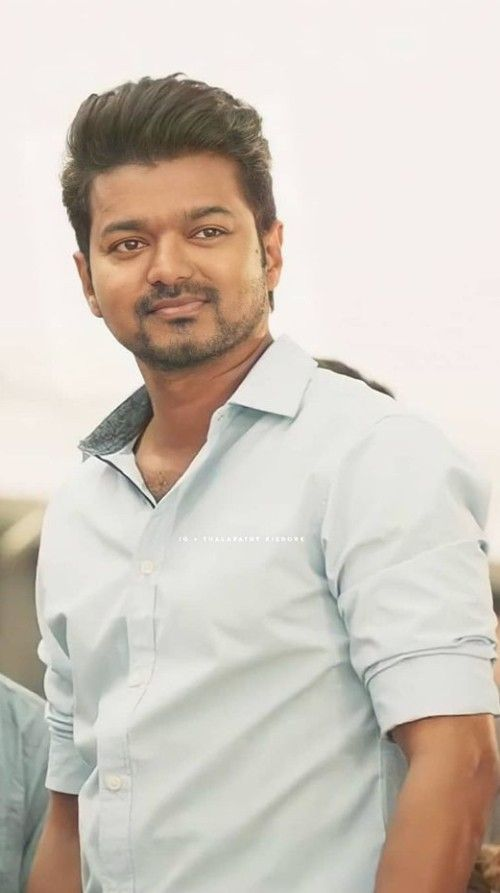

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[[0.56063116 0.42967364]]
0
The person in the image is not wearing a mask


In [39]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')